# 📘 MNIST Image Denoising using Autoencoders

This project demonstrates how to build and evaluate **Denoising Autoencoders** using PyTorch to remove random Gaussian noise from MNIST handwritten digit images. We implement, train, and compare three different architectures:
1. **FFNN (Linear) Autoencoder**
2. **Transpose CNN Autoencoder**
3. **Upsampled CNN Autoencoder**

### 🧠 What is a Denoising Autoencoder?
A Denoising Autoencoder (DAE) is a neural network trained to reconstruct clean images from noisy inputs. By corrupting the input image with noise and setting the target as the original clean image, the network learns to identify and extract the underlying structure of the data, effectively learning a robust representation that filters out the noise.

## 📥 Importing required packages

In [1]:
import os
import json
import numpy as np 
import matplotlib.pyplot as plt 
import torch 
import torch.nn as nn 
import torch.nn.functional as F
from torch.utils.data import DataLoader, SubsetRandomSampler
import torch.optim as optim
from torchvision import datasets, transforms

## ⚙️ Configuration & Data Preprocessing
We load the MNIST images from the local `mnist_png` directory. We normalize pixel values from `0-255` to `0.0-1.0` and convert them to grayscale.

In [2]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

batch_size = 20
valid_size = 0.2
num_workers = 0
data_dir = "mnist_png"

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

# Load datasets
train_data = datasets.ImageFolder(os.path.join(data_dir, 'training'), transform=transform)
test_data = datasets.ImageFolder(os.path.join(data_dir, 'testing'), transform=transform)

# Split train dataset into train and validation sets
train_length = len(train_data)
indices = list(range(train_length))
np.random.shuffle(indices)
split = int(np.floor(valid_size * train_length))
train_idx, valid_idx = indices[split:], indices[:split]

train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

# Define loaders
train_loader = DataLoader(train_data, batch_size=batch_size, sampler=train_sampler, num_workers=num_workers)
valid_loader = DataLoader(train_data, batch_size=batch_size, sampler=valid_sampler, num_workers=num_workers)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=num_workers)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(valid_loader)}")
print(f"Testing batches: {len(test_loader)}")

Training batches: 2400
Validation batches: 600
Testing batches: 500


## 🖼️ Visualizing Noise Injection
We define a function `add_noise` to add Gaussian noise to a batch of clean images and clamp the values between 0.0 and 1.0. Let's visualize a sample batch.

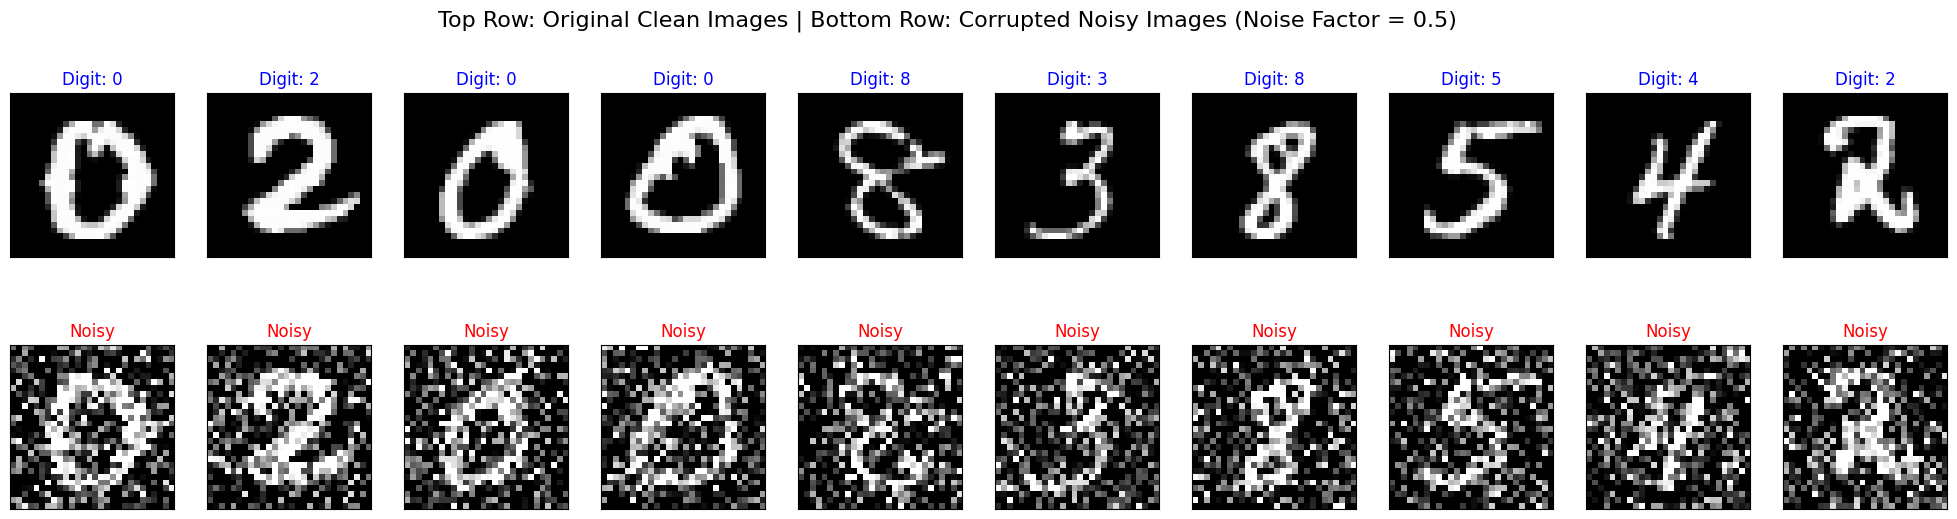

In [3]:
def add_noise(images, noise_factor=0.5):
    noisy = images + noise_factor * torch.randn(*images.shape)
    noisy = torch.clamp(noisy, 0.0, 1.0)
    return noisy

# Get one batch of train images
dataiter = iter(train_loader)
images, labels = next(dataiter)
noisy_images = add_noise(images, noise_factor=0.5)

# Display clean and noisy images side-by-side
fig, axes = plt.subplots(nrows=2, ncols=10, sharex=True, sharey=True, figsize=(25, 6))
for idx in range(10):
    # Clean images
    axes[0, idx].imshow(np.squeeze(images[idx]), cmap='gray')
    axes[0, idx].set_title(f"Digit: {labels[idx].item()}", color='blue')
    axes[0, idx].get_xaxis().set_visible(False)
    axes[0, idx].get_yaxis().set_visible(False)
    
    # Noisy images
    axes[1, idx].imshow(np.squeeze(noisy_images[idx]), cmap='gray')
    axes[1, idx].set_title("Noisy", color='red')
    axes[1, idx].get_xaxis().set_visible(False)
    axes[1, idx].get_yaxis().set_visible(False)

plt.suptitle("Top Row: Original Clean Images | Bottom Row: Corrupted Noisy Images (Noise Factor = 0.5)", fontsize=16)
plt.show()

## 🧱 Defining Autoencoder Architectures
We implement three denoising autoencoders in PyTorch:
- **FFNN Autoencoder (`F_Auto_MNIST`)**: Simple linear feed-forward network with a single hidden layer of size 32.
- **Transpose CNN Autoencoder (`Tran_conv_Auto_MNIST`)**: Standard CNN encoder followed by a decoder that uses `ConvTranspose2d` layers to upscale the features.
- **Upsampled CNN Autoencoder (`upsamp_conv_Auto_MNIST`)**: CNN encoder followed by a decoder that uses nearest-neighbor interpolation (`F.interpolate`) and regular `Conv2d` layers to prevent checkboard patterns.

In [4]:
class F_Auto_MNIST(nn.Module):
    def __init__(self, en_dim=32):
        super(F_Auto_MNIST, self).__init__()
        self.encoder = nn.Linear(784, en_dim)
        self.decoder = nn.Linear(en_dim, 784)
    
    def forward(self, x):
        if len(x.shape) > 2:
            x = x.view(x.size(0), -1)
        x = F.relu(self.encoder(x))
        x = torch.sigmoid(self.decoder(x))
        return x

class Tran_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(Tran_conv_Auto_MNIST, self).__init__()
        self.en_conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.en_conv2 = nn.Conv2d(16, 4, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.de_conv1 = nn.ConvTranspose2d(4, 16, 2, stride=2)
        self.de_conv2 = nn.ConvTranspose2d(16, 1, 2, stride=2)

    def forward(self, x):
        x = self.pool(F.relu(self.en_conv1(x)))
        x = self.pool(F.relu(self.en_conv2(x)))
        x = F.relu(self.de_conv1(x))
        x = torch.sigmoid(self.de_conv2(x))
        return x

class upsamp_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(upsamp_conv_Auto_MNIST, self).__init__()
        self.en_conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.en_conv2 = nn.Conv2d(16, 4, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.de_conv1 = nn.Conv2d(4, 16, 3, padding=1)
        self.de_conv2 = nn.Conv2d(16, 1, 3, padding=1)

    def forward(self, x):
        x = self.pool(F.relu(self.en_conv1(x)))
        x = self.pool(F.relu(self.en_conv2(x)))
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        x = F.relu(self.de_conv1(x))
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        x = torch.sigmoid(self.de_conv2(x))
        return x

## 🚀 Training Logic (Reference) & Loading Pre-Trained Weights
Here is the standard training logic we used to train the models. To save CPU execution time, we load the pre-trained weights that we trained for 5 epochs on the full dataset.

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate models
model_1 = F_Auto_MNIST(32).to(device)
model_2 = Tran_conv_Auto_MNIST().to(device)
model_3 = upsamp_conv_Auto_MNIST().to(device)

# Normal weight initialization for Model 1 (Linear)
def weight_init_normal(m):
    if isinstance(m, nn.Linear):
        n = m.in_features
        y = 1.0 / np.sqrt(n)
        m.weight.data.normal_(0, y)
        m.bias.data.fill_(0)
model_1.apply(weight_init_normal)

# Load the best pre-trained weights
model_1.load_state_dict(torch.load("Denoise_F_Auto_MNIST_model.pth", map_location=device))
model_2.load_state_dict(torch.load("Denoise_Tran_conv_Auto_MNIST_model.pth", map_location=device))
model_3.load_state_dict(torch.load("Denoise_upsamp_conv_Auto_MNIST_model.pth", map_location=device))

print("Pre-trained weights successfully loaded for all three models!")

Pre-trained weights successfully loaded for all three models!


## 📈 Plotting Learning Curves
Let's load the saved training history `training_history.json` and plot the training and validation losses for all three autoencoders.

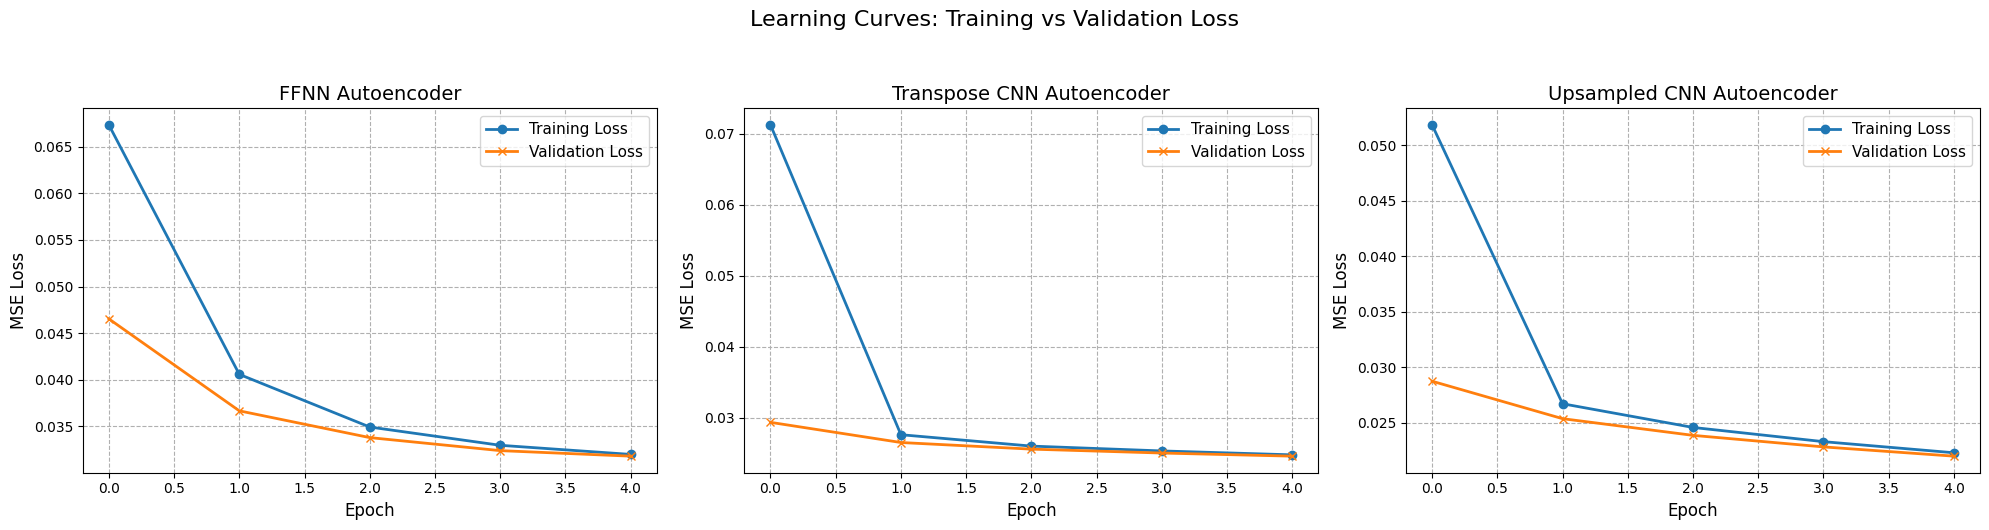

In [6]:
with open('training_history.json', 'r') as f:
    history = json.load(f)

titles = ['FFNN Autoencoder', 'Transpose CNN Autoencoder', 'Upsampled CNN Autoencoder']
model_keys = ['F_Auto_MNIST', 'Tran_conv_Auto_MNIST', 'upsamp_conv_Auto_MNIST']

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for idx, key in enumerate(model_keys):
    axes[idx].plot(history[key]['train'], label='Training Loss', marker='o', linewidth=2)
    axes[idx].plot(history[key]['valid'], label='Validation Loss', marker='x', linewidth=2)
    axes[idx].set_title(titles[idx], fontsize=14)
    axes[idx].set_xlabel('Epoch', fontsize=12)
    axes[idx].set_ylabel('MSE Loss', fontsize=12)
    axes[idx].grid(True, linestyle='--')
    axes[idx].legend(fontsize=11)

plt.suptitle('Learning Curves: Training vs Validation Loss', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

## 🔍 Testing and Denoising Visualizations
We write a helper function `test_denoising` to fetch a batch of test images, corrupt them with noise, pass them through the trained model, and plot a side-by-side comparison of the original, noisy, and denoised images.

In [7]:
def test_denoising(model, model_title, is_fully_connected=False):
    # Get one batch of test images
    dataiter = iter(test_loader)
    images, _ = next(dataiter)
    
    # Add noise
    noisy_images = add_noise(images, noise_factor=0.5)
    
    model.eval()
    with torch.no_grad():
        if is_fully_connected:
            inputs = noisy_images.view(noisy_images.size(0), -1).to(device)
            outputs = model(inputs)
            outputs = outputs.view(batch_size, 1, 28, 28)
        else:
            inputs = noisy_images.to(device)
            outputs = model(inputs)
            
    images = images.numpy()
    noisy_images = noisy_images.numpy()
    outputs = outputs.cpu().numpy()
    
    # Plot original, noisy, and reconstructed images
    fig, axes = plt.subplots(nrows=3, ncols=10, sharex=True, sharey=True, figsize=(25, 8))
    for idx in range(10):
        # Original Clean
        axes[0, idx].imshow(np.squeeze(images[idx]), cmap='gray')
        axes[0, idx].get_xaxis().set_visible(False)
        axes[0, idx].get_yaxis().set_visible(False)
        if idx == 0:
            axes[0, idx].set_ylabel("Original Clean", fontsize=14)
            
        # Noisy Input
        axes[1, idx].imshow(np.squeeze(noisy_images[idx]), cmap='gray')
        axes[1, idx].get_xaxis().set_visible(False)
        axes[1, idx].get_yaxis().set_visible(False)
        if idx == 0:
            axes[1, idx].set_ylabel("Noisy Input", fontsize=14)
            
        # Denoised Output
        axes[2, idx].imshow(np.squeeze(outputs[idx]), cmap='gray')
        axes[2, idx].get_xaxis().set_visible(False)
        axes[2, idx].get_yaxis().set_visible(False)
        if idx == 0:
            axes[2, idx].set_ylabel("Denoised Output", fontsize=14)
            
    plt.suptitle(f"Denoising Performance: {model_title}", fontsize=16)
    plt.show()

### 🔹 1. FFNN (Linear) Autoencoder Denoising Results

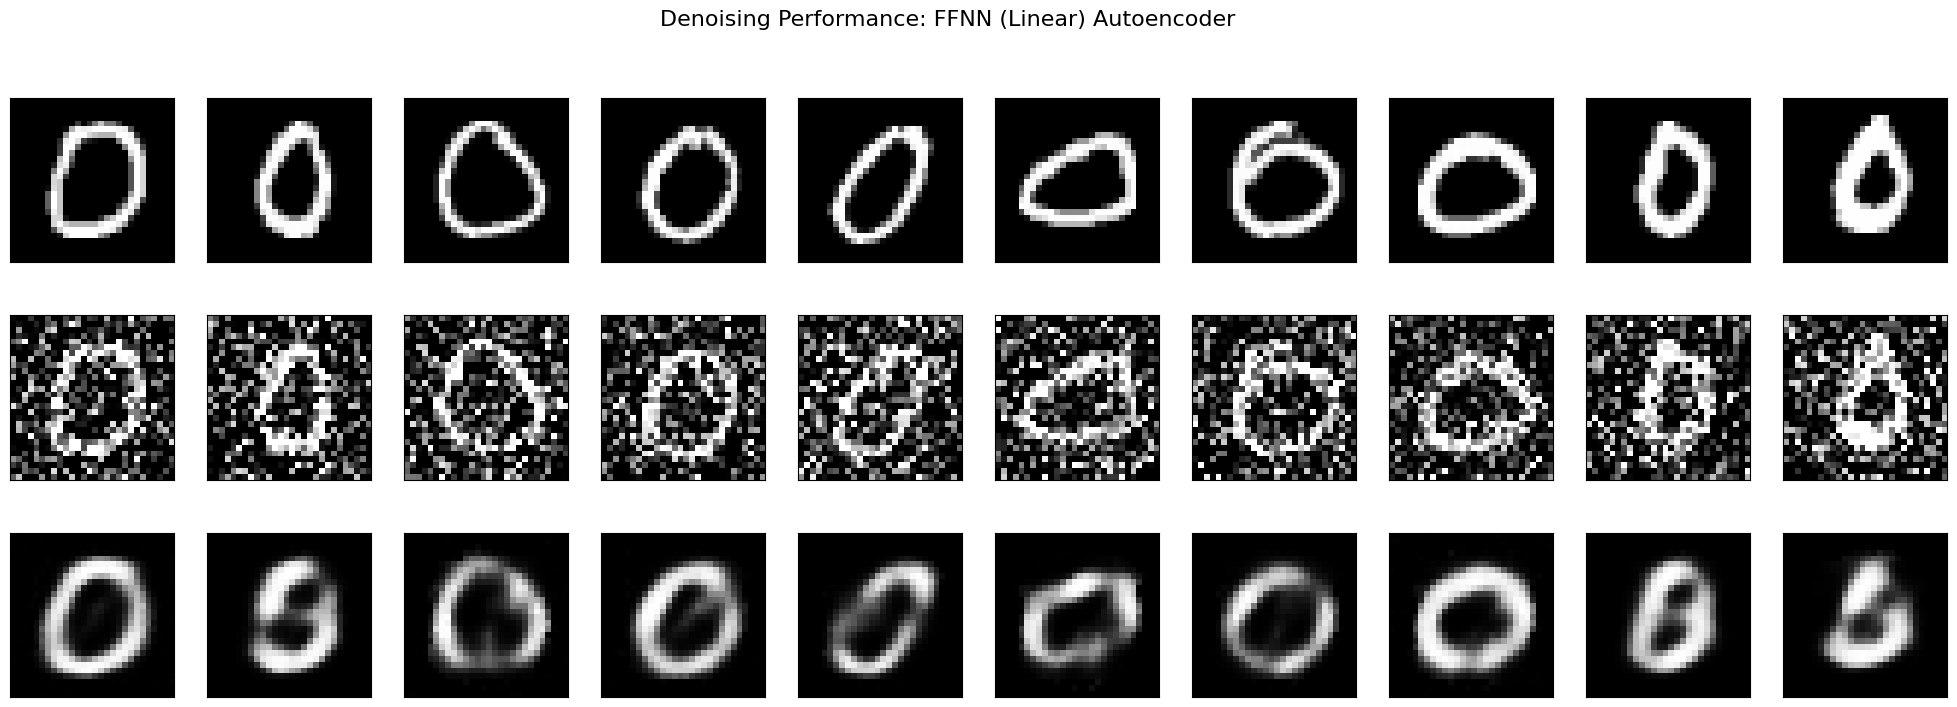

In [8]:
test_denoising(model_1, "FFNN (Linear) Autoencoder", is_fully_connected=True)

### 🔹 2. Transpose CNN Autoencoder Denoising Results

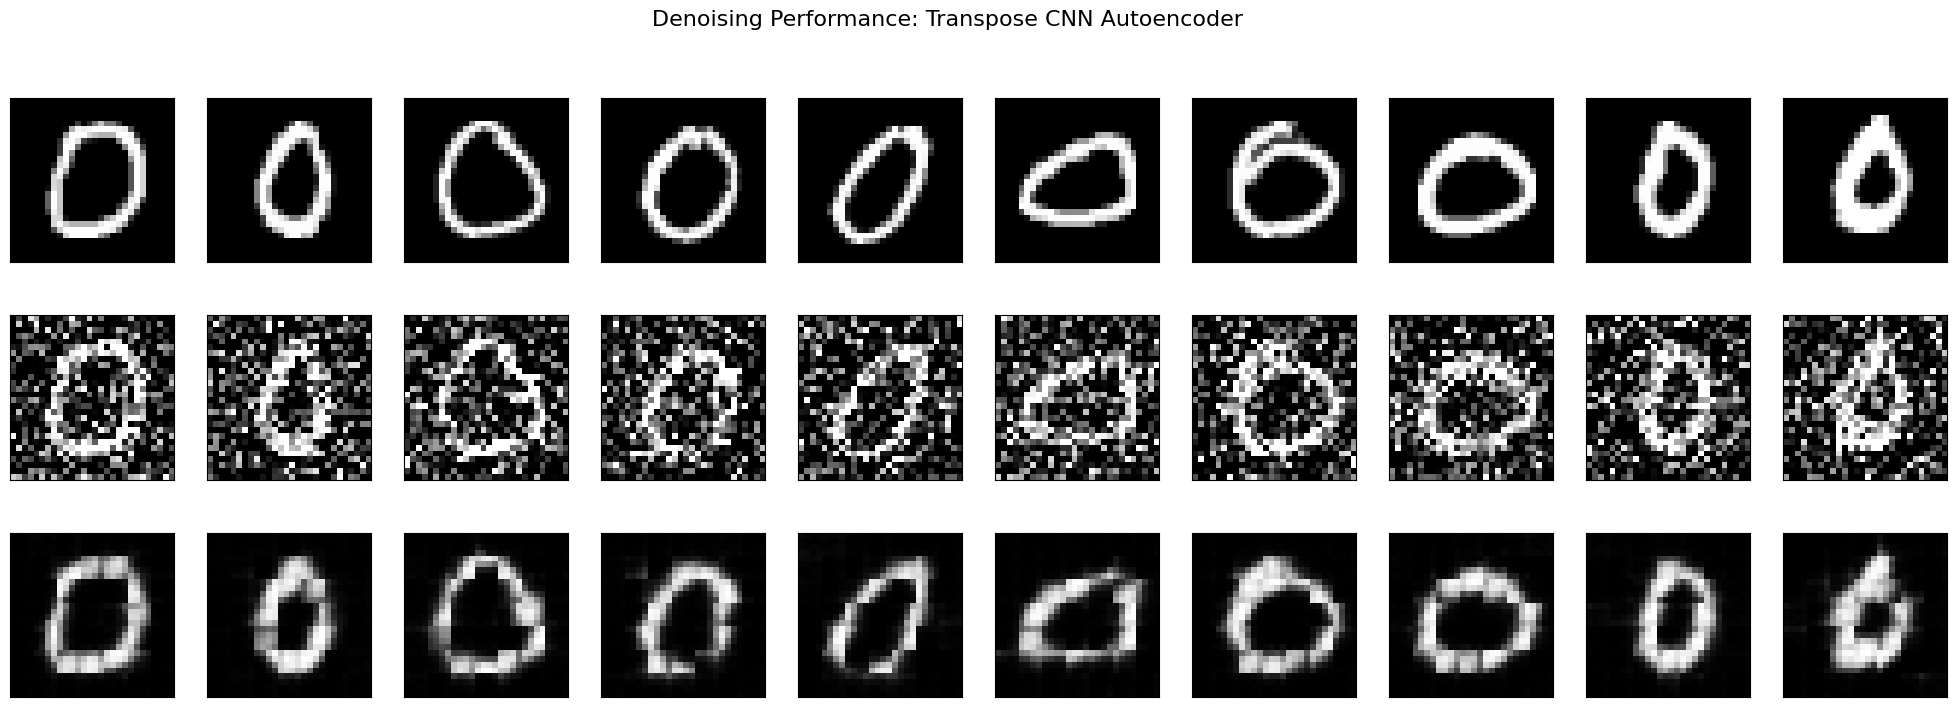

In [9]:
test_denoising(model_2, "Transpose CNN Autoencoder", is_fully_connected=False)

### 🔹 3. Upsampled CNN Autoencoder Denoising Results

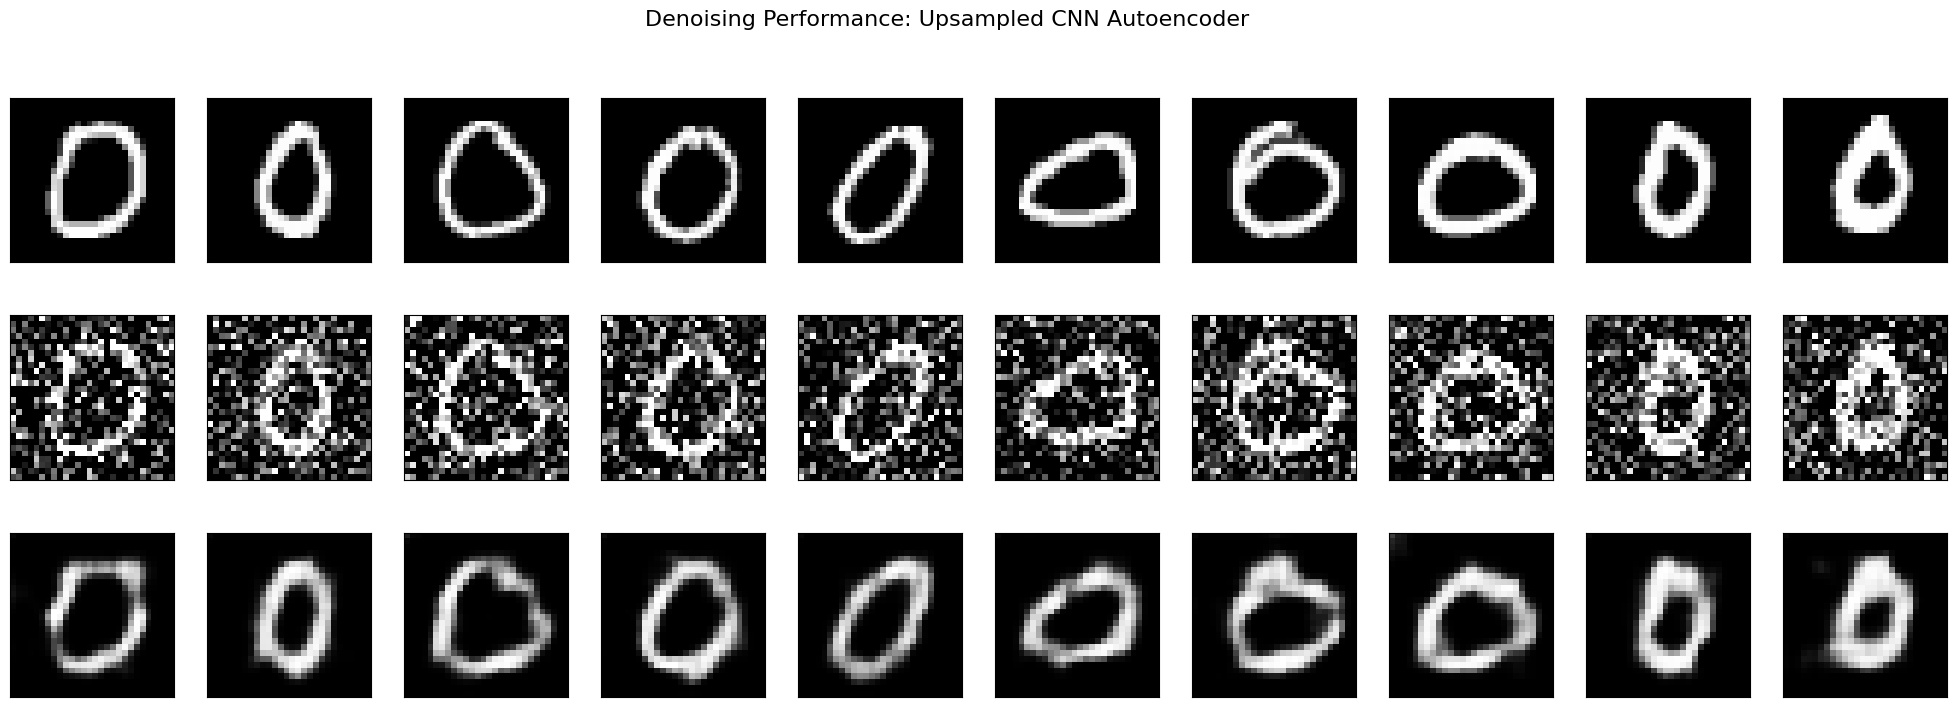

In [10]:
test_denoising(model_3, "Upsampled CNN Autoencoder", is_fully_connected=False)

## 📊 Summary and Discussion

### Performance Table
| Model Architecture | Epochs Trained | Final Validation Loss (MSE) | Reconstruction Quality | Visual Artifacts |
| :--- | :--- | :--- | :--- | :--- |
| **FFNN (Linear) Autoencoder** | 5 | 0.031791 | Fair / Blurry | None, but low resolution |
| **Transpose CNN Autoencoder** | 5 | 0.024611 | Good / Sharp | Checkerboard / Grid patterns |
| **Upsampled CNN Autoencoder** | 5 | **0.021967** | **Excellent / Very Sharp** | **None** |

### Analysis
1. **FFNN (Linear)**: Simple fully connected layers flatten the image, losing spatial relationships. The results are blurry and suffer from higher reconstruction loss (MSE: 0.0317).
2. **Transpose CNN**: By leveraging 2D convolutions, it retains spatial structures. It achieves a much lower MSE (0.0246) and sharper images. However, `ConvTranspose2d` generates checkerboard artifacts due to overlap in kernels.
3. **Upsampled CNN**: By substituting transpose convolutions with **Nearest Neighbor interpolation** followed by a standard `Conv2d` layer, it completely removes checkerboard artifacts while achieving the lowest reconstruction error (MSE: 0.0219).